In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("childrends.csv")
print(df)

                                          Title        Date Month Fiscal Year  \
0                   Me and You-kelele Storytime  07/01/2016   Jul       FY 17   
1     MC Infants & Toddlers Bilingual Storytime  07/01/2016   Jul       FY 17   
2                                  lego weekend  07/01/2016   Jul       FY 17   
3                                 LEGO Playtime  07/01/2016   Jul       FY 17   
4                                     LEGO Crew  07/01/2016   Jul       FY 17   
...                                         ...         ...   ...         ...   
1776                                 Act it Out  06/29/2017   Jun       FY 17   
1777  MC Infants & Toddlers Bilingual Storytime  06/30/2017   Jun       FY 17   
1778                     Lego Construction Crew  06/30/2017   Jun       FY 17   
1779                    LEGO and DUPLO Playtime  06/30/2017   Jun       FY 17   
1780                                  LEGO Crew  06/30/2017   Jun       FY 17   

                           

In [17]:
df.head()
df.tail()

,Title,Date,Month,Fiscal Year,Library,Primary Event Type,Event Type Option 1,Event Type Option 2,Primary Age Group,Age Group Option 1,Age Group Option 2,Description,Published Status,Attendance
1776,Act it Out,06/29/2017,Jun,FY 17,Olney,Storytime,ACE - All Children Excel,Makerspace,Elementary School Age,Preschool and Kindergarten,Elementary School Age,We will read a story and then the kids will ac...,Yes,9.0
1777,MC Infants & Toddlers Bilingual Storytime,06/30/2017,Jun,FY 17,Gaithersburg,Z_Visits In,Storytime,Makerspace,Babies and Toddlers,Preschool and Kindergarten,Elementary School Age,open bilingual storytime hosted in the library...,No,30.0
1778,Lego Construction Crew,06/30/2017,Jun,FY 17,Olney,Science & Math (STEM),ACE - All Children Excel,Makerspace,Elementary School Age,Preschool and Kindergarten,Elementary School Age,Drop in every Friday afternoon between 3:30 an...,Yes,23.0
1779,LEGO and DUPLO Playtime,06/30/2017,Jun,FY 17,Twinbrook,Makerspace,ACE - All Children Excel,Science & Math (STEM),Elementary School Age,Preschool and Kindergarten,Elementary School Age,Drop-in for an open session of imaginative con...,Yes,NaN
1780,LEGO Crew,06/30/2017,Jun,FY 17,Gaithersburg,Science & Math (STEM),ACE - All Children Excel,Makerspace,Elementary School Age,Preschool and Kindergarten,Elementary School Age,Come showcase your creativity at this free dro...,Yes,27.0


In [19]:
df.isnull().sum()

Title                  0
Date                   0
Month                  0
Fiscal Year            0
Library                0
Primary Event Type     0
Event Type Option 1    0
Event Type Option 2    0
Primary Age Group      0
Age Group Option 1     0
Age Group Option 2     0
Description            0
Published Status       0
Attendance             0
dtype: int64

In [6]:
df["Event Type Option 2"]=df["Event Type Option 2"].fillna(df["Event Type Option 2"].mode()[0])

In [10]:
df["Age Group Option 1"]=df["Age Group Option 1"].fillna(df["Age Group Option 1"].mode()[0])

In [12]:
df["Age Group Option 2"]=df["Age Group Option 2"].fillna(df["Age Group Option 2"].mode()[0])

In [16]:
df.drop("Internal Notes",axis=1,inplace=True)

In [18]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())

In [20]:
import plotly.express as px

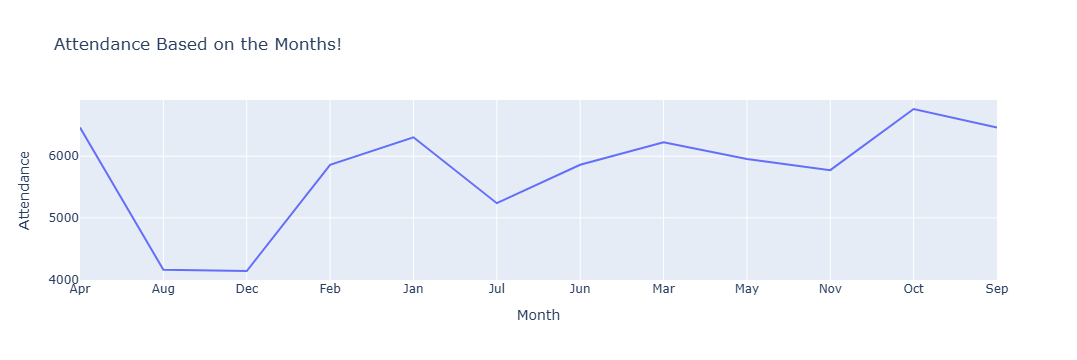

In [24]:
attndnce = df.groupby('Month')['Attendance'].sum().reset_index()
fig = px.line(attndnce, x='Month', y='Attendance',title = 'Attendance Based on the Months!')
fig.show()

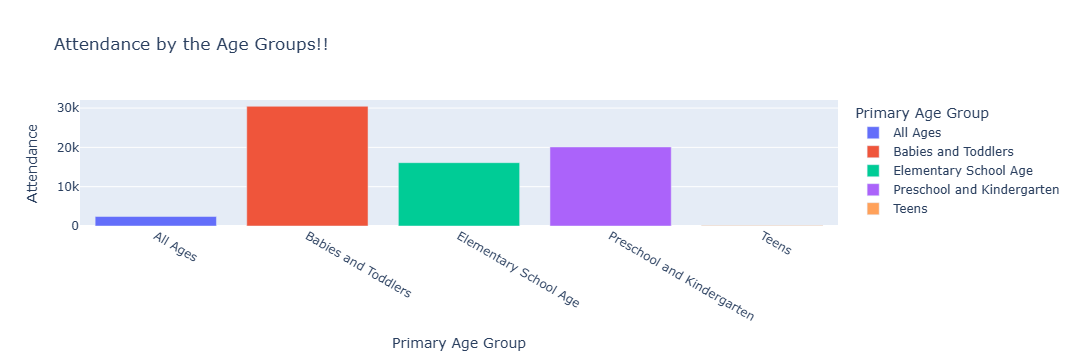

In [32]:
agegrp = df.groupby('Primary Age Group')['Attendance'].sum().reset_index()
fig = px.bar(agegrp, x='Primary Age Group', y='Attendance', color='Primary Age Group',title = 'Attendance by the Age Groups!!')
fig.show()

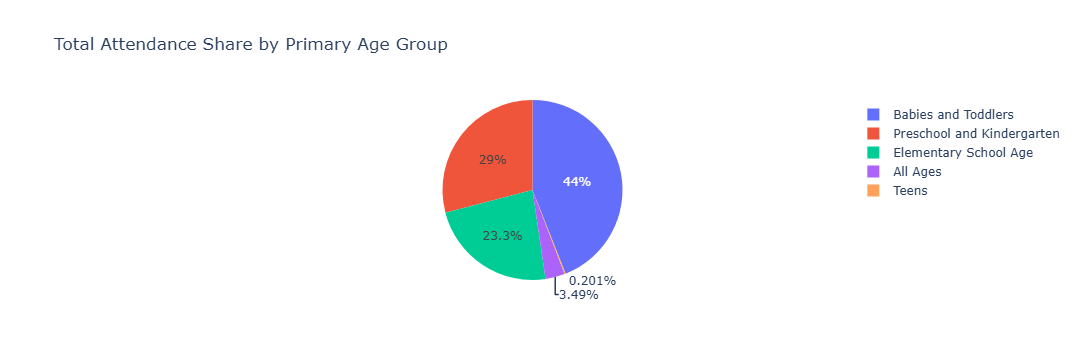

In [34]:
fig = px.pie(agegrp, names='Primary Age Group',values='Attendance', title='Total Attendance Share by Primary Age Group')
fig.show()

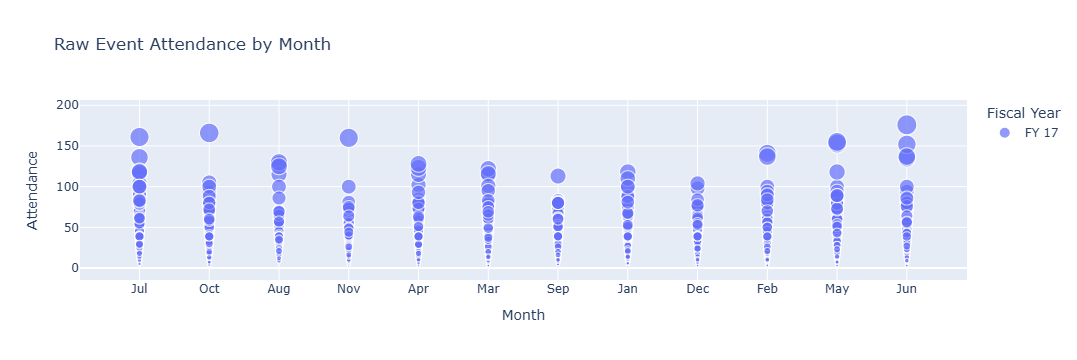

In [36]:
fig = px.scatter(df, x='Month',y='Attendance', color='Fiscal Year',size="Attendance",title='Raw Event Attendance by Month')
fig.show()

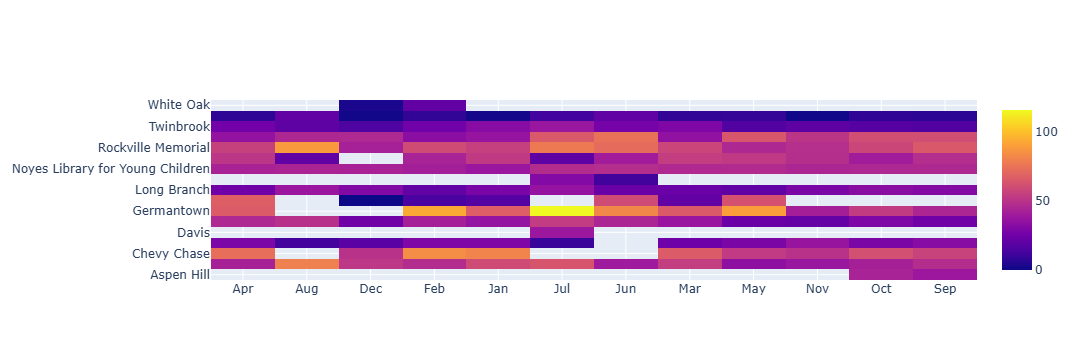

In [38]:
import plotly.graph_objects as go
pivot_df = df.pivot_table(values='Attendance', index='Library', columns='Month')
fig = go.Figure(data=go.Heatmap(z=pivot_df, x=pivot_df.columns, y=pivot_df.index))
fig.show()